In [1]:
%load_ext autoreload
%autoreload 2

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from env.charging_env import ChargingStationEnv
from metrics.validate import report_queueing_laws, validate_episode
from offline_opt import (
    StationSpec,
    build_offline_model,
    build_relaxed_model,
    default_horizon_minutes,
    extract_solution,
    solve_offline_model,
    taper_time_constant,
    vehicles_from_evs,
)
from policy.power.proportional import ProportionalPower
from policy.power.static import StaticPower
from policy.queue.fifo import FIFOQueuePolicy
from policy.queue.lowest_soc_diff import LowestSoCDiffQueuePolicy
from visualization.ev_curves import plot_ev_theory_vs_sim
from visualization.pile_power import plot_pile_connector_power
from config import MAX_TIME



In [2]:
# Shared station / traffic inputs (simulation and offline use the same layout).
SCENARIO = {
    "n_piles": 1,
    "n_connectors": 2,
    "n_modules": 6,
    "p_module": 25.0,
    "queue_capacity": 1000,
    "mean_interarrival": 75.0,
}

# Simulation controls
SEED = 42
POLICY_SEED = 1
QUEUE_POLICY = FIFOQueuePolicy()
POWER_POLICY = ProportionalPower()



In [3]:
env = ChargingStationEnv(
    **SCENARIO,
    power_policy=POWER_POLICY,
)

obs, info = env.reset(seed=SEED)
done = False
rng = np.random.default_rng(POLICY_SEED)
policy = QUEUE_POLICY
total_reward = 0.0

t0 = time.perf_counter()
while not done:
    mask = env.action_masks()
    ev, pile_id = policy.decide(obs, mask, rng, env.engine.station)
    obs, reward, done, _, info = env.step(pile_id, ev=ev)
    total_reward += reward
sim_runtime = time.perf_counter() - t0

finished = env.engine.metrics.finished_evs
arrived = env.engine.metrics.arrived_evs
dropped = env.engine.metrics.dropped_evs
sim_total_sojourn = float(
    sum(ev.departure_time - ev.arrival_time for ev in finished)
)
sim_mean_sojourn = env.engine.metrics.mean_sojourn()

In [4]:
print(f"Finished EVs: {len(finished)}")
print(f"Arrived EVs:  {len(arrived)}")
print(f"Dropped EVs:  {len(dropped)}")
print(f"Avg L: {env.engine.metrics.average_L():.3f}")
print(f"Avg Q: {env.engine.metrics.average_Q():.3f}")
print(f"Total reward: {total_reward:.3f}")
print(f"Sim time (episode clock): {env.engine.current_time:.1f} min")
print(f"Sim wall-clock runtime:   {sim_runtime:.3f} s")
print(f"Sim total sojourn (finished): {sim_total_sojourn:.2f} min")
print(f"Sim mean sojourn (finished):  {sim_mean_sojourn:.2f} min")

Finished EVs: 6
Arrived EVs:  6
Dropped EVs:  0
Avg L: 0.313
Avg Q: 0.027
Total reward: -19.449
Sim time (episode clock): 720.0 min
Sim wall-clock runtime:   0.004 s
Sim total sojourn (finished): 225.61 min
Sim mean sojourn (finished):  37.60 min


In [5]:
# Offline IP + continuous relaxations on the same station layout and the same
# arrival stream the episode already realized (no synthetic arrivals after
# simulation end). VehicleData uses each EV's arrival, battery, s_i, s_f.
offline_station = StationSpec(
    n_piles=SCENARIO["n_piles"],
    n_connectors=SCENARIO["n_connectors"],
    n_modules=SCENARIO["n_modules"],
    p_module=SCENARIO["p_module"],
)

# Offline MILP / RP controls (same arrivals + station as the finished episode)
DELTA = 1.0
MIP_GAP = 1e-3
TIME_LIMIT = 600.0  # seconds per solve; raise if the gap does not close
# Manual completion horizon for the offline models (minutes). Must be long
# enough that every arrived EV can finish. Arrival list is cut at sim end;
# this horizon is only the MILP's planning window T, not an arrival generator.
OFFLINE_HORIZON = MAX_TIME

sim_end = float(env.engine.current_time)
# Arrivals that occurred by simulation end only (engine already stops at
# MAX_TIME / SIM_OVER; the filter makes the cutoff explicit).
offline_evs = [ev for ev in arrived if ev.arrival_time <= sim_end + 1e-9]
vehicles = vehicles_from_evs(offline_evs)
tau = taper_time_constant()

# Manual planning horizon T for the MILP (must cover finishing every vehicle).
horizon = float(OFFLINE_HORIZON)


full_cap = offline_station.n_modules * offline_station.p_module
reduced_cap = (
    offline_station.n_modules - offline_station.n_connectors + 1
) * offline_station.p_module

print(
    f"Offline instance: J={len(vehicles)} vehicles "
    f"(arrived by sim_end={sim_end:.1f} min), "
    f"horizon T={horizon:.1f} min, delta={DELTA:g} min, "
    f"full_cap={full_cap:g} kW, reduced_cap={reduced_cap:g} kW"
)

Offline instance: J=6 vehicles (arrived by sim_end=720.0 min), horizon T=720.0 min, delta=1 min, full_cap=150 kW, reduced_cap=125 kW


In [6]:
ip_model = build_offline_model(
    vehicles,
    offline_station,
    delta=DELTA,
    horizon_minutes=horizon,
    tau=tau,
    break_pile_symmetry=True,
    tie_break=False,
)
solve_offline_model(ip_model, mip_gap=MIP_GAP, time_limit=TIME_LIMIT, verbose=True)
ip_sol = extract_solution(ip_model)
print("Done solving IP")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2616613
Academic license 2616613 - for non-commercial use only - registered to m.___@mail.utoronto.ca
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.001
Set parameter TimeLimit to value 600
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1145G7 @ 2.60GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.001

Academic license 2616613 - for non-commercial use only - registered to m.___@mail.utoronto.ca
Optimize a model with 17489 rows, 7301 columns and 546501 nonzeros (Min)
Model fingerprint: 0x5cd50013
Model has 1459 linear objective coefficients and an objective constant of 1.4617378434695320e+03
Variable types: 2918 continuous, 4383 integer (2924 binary)
Coefficient statistics:
  Matrix range 

In [7]:
ip_sol

OfflineSolution(status='OPTIMAL', objective=220.73784265827726, total_sojourn=220.73784265827712, mean_sojourn=36.78964044304619, mip_gap=1.5100452185441935e-11, runtime=74.30999994277954, n_vehicles=6, delta=1.0, per_vehicle=   vehicle_id     arrival  pile  service_start   departure    sojourn  \
0           0  180.315645     0          181.0  205.000000  24.684355   
1           1  355.529869     0          356.0  399.000000  43.470131   
2           2  534.386944     0          535.0  571.000000  36.613056   
3           3  555.371516     0          571.0  608.000000  52.628484   
4           4  561.854321     0          562.0  596.999999  35.145678   
5           5  670.803860     0          671.0  699.000000  28.196140   

   finished  energy_kwh  energy_required_kwh  
0      True   30.601557            30.601557  
1      True   90.709491            90.709491  
2      True   73.813528            73.813528  
3      True   49.757207            49.757207  
4      True   35.538729    

In [8]:
rp_lo_model = build_relaxed_model(
    vehicles,
    offline_station,
    delta=DELTA,
    horizon_minutes=horizon,
    tau=tau,
    pile_capacity_kw=full_cap,
)
solve_offline_model(rp_lo_model, mip_gap=MIP_GAP, time_limit=TIME_LIMIT)
rp_lower = extract_solution(rp_lo_model)
print("Done solving RP_lower.")

Done solving RP_lower.


In [9]:
rp_up_model = build_relaxed_model(
    vehicles,
    offline_station,
    delta=DELTA,
    horizon_minutes=horizon,
    tau=tau,
    pile_capacity_kw=reduced_cap,
)
solve_offline_model(rp_up_model, mip_gap=MIP_GAP, time_limit=TIME_LIMIT)
rp_upper = extract_solution(rp_up_model)
print("Done solving RP_upper.")


Done solving RP_upper.


In [10]:
# Solver status and MIP gap for the offline models
status_gap = pd.DataFrame(
    [
        {
            "model": "IP",
            "status": ip_sol.status,
            "mip_gap": ip_sol.mip_gap,
        },
        {
            "model": "RP_lower (full cap)",
            "status": rp_lower.status,
            "mip_gap": rp_lower.mip_gap,
        },
        {
            "model": "RP_upper (reduced cap)",
            "status": rp_upper.status,
            "mip_gap": rp_upper.mip_gap,
        },
    ]
).set_index("model")
status_gap


,status,mip_gap
model,,
IP,OPTIMAL,1.510045e-11
RP_lower (full cap),OPTIMAL,0.000000e+00
RP_upper (reduced cap),OPTIMAL,0.000000e+00


In [11]:
# Runtime and sojourn: offline models vs the causal simulation.
# Offline totals include every EV that arrived by sim end (MILP forces finish
# by OFFLINE_HORIZON). Simulation totals are over finished EVs only; EVs still
# plugged or waiting at sim end are excluded from sim sojourn.
compare = pd.DataFrame(
    [
        {
            "model": "RP_lower",
            "status": rp_lower.status,
            "runtime_s": rp_lower.runtime,
            "total_sojourn_min": rp_lower.total_sojourn,
            "mean_sojourn_min": rp_lower.mean_sojourn,
            "n_vehicles": rp_lower.n_vehicles,
        },
        {
            "model": "IP",
            "status": ip_sol.status,
            "runtime_s": ip_sol.runtime,
            "total_sojourn_min": ip_sol.total_sojourn,
            "mean_sojourn_min": ip_sol.mean_sojourn,
            "n_vehicles": ip_sol.n_vehicles,
        },
        {
            "model": "RP_upper",
            "status": rp_upper.status,
            "runtime_s": rp_upper.runtime,
            "total_sojourn_min": rp_upper.total_sojourn,
            "mean_sojourn_min": rp_upper.mean_sojourn,
            "n_vehicles": rp_upper.n_vehicles,
        },
        {
            "model": "Simulation",
            "status": "-",
            "runtime_s": sim_runtime,
            "total_sojourn_min": sim_total_sojourn,
            "mean_sojourn_min": sim_mean_sojourn,
            "n_vehicles": len(finished),
        },
    ]
).set_index("model")

print(
    f"Arrived by sim end={len(offline_evs)}, finished={len(finished)}, "
    f"dropped={len(dropped)}, still in system at end="
    f"{len(offline_evs) - len(finished) - len(dropped)}."
)
print(
    "Expected sandwich when IP is optimal:\n"
    "  RP_lower.total_sojourn <= IP <= RP_upper, and IP <= Simulation "
    "(on the same finished set / when the episode clears everyone)."
)
compare


Arrived by sim end=6, finished=6, dropped=0, still in system at end=0.
Expected sandwich when IP is optimal:
  RP_lower.total_sojourn <= IP <= RP_upper, and IP <= Simulation (on the same finished set / when the episode clears everyone).


,status,runtime_s,total_sojourn_min,mean_sojourn_min,n_vehicles
model,,,,,
RP_lower,OPTIMAL,35.281000,218.737843,36.456307,6
IP,OPTIMAL,74.310000,220.737843,36.789640,6
RP_upper,OPTIMAL,38.754000,243.737843,40.622974,6
Simulation,-,0.007917,225.608021,37.601337,6


In [ ]:
# Dantzig-Wolfe decomposition (offline_opt_dw) on the *same* vehicles,
# station, delta, horizon and tau as the IP/RP models above -- see
# offline_opt_dw/README.md. Instead of one point estimate, it returns a
# certified [Z_lb, Z_ub] bracket on the offline optimum, valid even if
# column generation has not fully converged.
from offline_opt_dw import solve_by_decomposition

dw_sol, dw_colgen = solve_by_decomposition(
    vehicles,
    offline_station,
    delta=DELTA,
    horizon_minutes=horizon,
    tau=tau,
    time_limit=TIME_LIMIT,
    progress=True,
)

[colgen] iter 1: Z_RMP=1229.000, LB_Z=1229.000, UB_Z=1741.500, gap=512.500, exact=True, candidates=4, added=4, total_columns=22
[colgen] iter 2: Z_RMP=1229.000, LB_Z=1229.000, UB_Z=1741.500, gap=512.500, exact=False, candidates=3, added=3, total_columns=25
[colgen] iter 3: Z_RMP=1229.000, LB_Z=1229.000, UB_Z=1741.500, gap=512.500, exact=False, candidates=3, added=3, total_columns=28
[colgen] iter 4: Z_RMP=1229.000, LB_Z=1229.000, UB_Z=1741.500, gap=512.500, exact=False, candidates=3, added=3, total_columns=31
[colgen] iter 5: Z_RMP=1229.000, LB_Z=1229.000, UB_Z=1741.500, gap=512.500, exact=False, candidates=3, added=3, total_columns=34
[colgen] iter 6: Z_RMP=1229.000, LB_Z=1229.000, UB_Z=1741.500, gap=512.500, exact=False, candidates=3, added=3, total_columns=37
[colgen] iter 7: Z_RMP=1229.000, LB_Z=1229.000, UB_Z=1741.500, gap=512.500, exact=False, candidates=3, added=3, total_columns=40
[colgen] iter 8: Z_RMP=1229.000, LB_Z=1229.000, UB_Z=1741.500, gap=512.500, exact=False, candidate

In [ ]:
print(f"DW status: {dw_sol.status}")
print(f"Z in [{dw_sol.Z_lb:g}, {dw_sol.Z_ub:g}]  (Z_fifo={dw_sol.Z_fifo:g})")
print(
    f"mean sojourn in [{dw_sol.mean_sojourn_lb_minutes:.3f}, "
    f"{dw_sol.mean_sojourn_ub_minutes:.3f}] min "
    "(ceiling from Z_ub, achieved schedule's own mean from Z_lb)"
)
print(
    f"iterations={dw_sol.iterations}, columns_generated={dw_sol.columns_generated}, "
    f"wall_clock_s={dw_sol.wall_clock_s:.3f}"
)

In [ ]:
dw_sol.per_vehicle

In [ ]:
# Add the DW bracket to the same comparison table. "DW_lb" uses Z_ub (the
# Lagrangian ceiling -- not necessarily achieved by any actual schedule);
# "DW_ub" is the mean sojourn actually realized by dw_sol.per_vehicle (what
# Z_lb realizes). Note the reversal: the *upper* bound on Z gives the
# *lower* end of the sojourn interval -- see offline_opt_dw/README.md,
# "Sign convention: this master maximises".
compare_dw = pd.concat(
    [
        compare,
        pd.DataFrame(
            [
                {
                    "model": "DW_lb (Z_ub ceiling)",
                    "status": dw_sol.status,
                    "runtime_s": dw_sol.wall_clock_s,
                    "total_sojourn_min": dw_sol.mean_sojourn_lb_minutes * dw_sol.n_vehicles,
                    "mean_sojourn_min": dw_sol.mean_sojourn_lb_minutes,
                    "n_vehicles": dw_sol.n_vehicles,
                },
                {
                    "model": "DW_ub (achieved schedule)",
                    "status": dw_sol.status,
                    "runtime_s": dw_sol.wall_clock_s,
                    "total_sojourn_min": dw_sol.mean_sojourn_ub_minutes * dw_sol.n_vehicles,
                    "mean_sojourn_min": dw_sol.mean_sojourn_ub_minutes,
                    "n_vehicles": dw_sol.n_vehicles,
                },
            ]
        ).set_index("model"),
    ]
)

print(
    "Expected sandwich: RP_lower <= DW_lb <= IP <= DW_ub <= RP_upper "
    "(DW_lb/DW_ub bracket the true optimum the same way RP_lower/RP_upper do)."
)
compare_dw

In [11]:
summary = env.engine.metrics.queueing_summary(env.engine.current_time)
waits, services, sojourns = env.engine.metrics.finished_time_arrays()
rep_val = validate_episode(env, verbose=True)
reo_q = report_queueing_laws(env, verbose=True)



=== Episode validation ===
  arrived=22, finished=22, dropped=0, queued=0, plugged=0
  [PASS] Finished: s_current ~= s_f: ok for all finished EVs
  [PASS] Finished: energy_received ~= c_b*(s_f-s_i)/HR2MIN: ok for all finished EVs
  [PASS] Finished: energy_received ~= energy_received_2: ok for all finished EVs
  [PASS] Finished: departure_time >= service_start_time >= arrival_time: ok for all finished EVs
  [PASS] Finished: pile_tracker / connector_id_tracker set: ok for all finished EVs
  [PASS] Finished: p_act <= p_req in charge_trace: ok for all finished EVs
  [PASS] Dropped: never got service_start_time / empty charge_trace: ok for all dropped EVs
  [PASS] arrived = finished + dropped + queued + plugged: 22 vs 22+0+0+0=22

=== Queueing laws ===
  T=1440.0 min, finished=22, c=2 servers
  lambda_eff=0.015278 /min
  E[W]=33.9919 min, E[W_q]=2.8279 min, E[S]=31.1640 min
  Little L = lambda_eff * W :  theory=0.5193  sim=0.5193  |diff|=0.0000
  Little Q = lambda_eff * W_q:  theory=0.0432

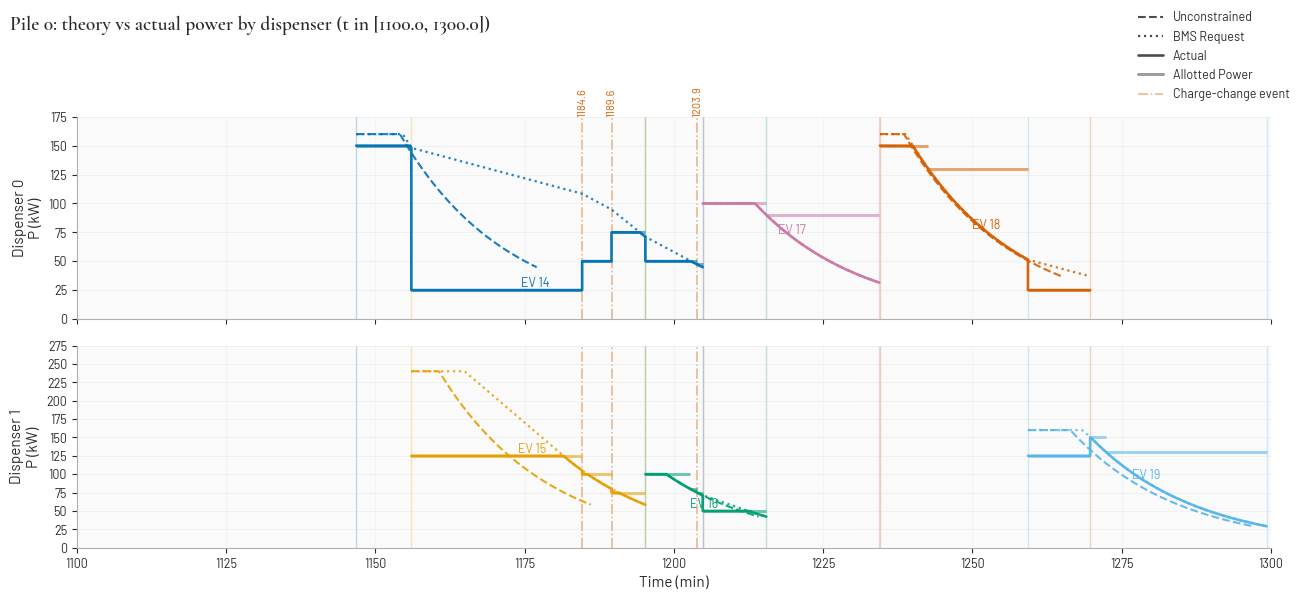

In [12]:
fig = plot_pile_connector_power(
    env,
    0,
    t_start=1100,
    t_end=1300,
    show_theory=True,
    show_sim_bms=True,
    show_actual=True,
    show_legend=True,
    label_theory="Unconstrained",
    label_sim_bms="BMS Request",
    label_actual="Actual",
    label_charge_steps="Allotted Power",
    show_charge_change_lines=True,
    show_charge_change_vlines=True,
    show_trace_labels=False,
    title=None,
    show_event_lines=True,
    event_line_alpha=0.25,
    show_ev_ids=True,
)
fig


In [7]:
from visualization.pile_power import plot_pile_connector_power
from offline_opt import plot_pile_power_and_modules_v2

PLOT_KW = dict(
    pile_id=0,
    t_start=1100,
    t_end=1300,
    show_theory=True,
    show_sim_bms=True,
    show_actual=True,
    show_legend=True,
    label_theory="Unconstrained",
    label_sim_bms="BMS Request",
    label_actual="Actual",
    label_charge_steps="Allotted Power",
    show_charge_change_lines=True,
    show_charge_change_vlines=True,
    show_trace_labels=False,
    show_event_lines=True,
    event_line_alpha=0.25,
    show_ev_ids=True,
)

fig_sim = plot_pile_connector_power(env, **PLOT_KW)
fig_opt = plot_pile_power_and_modules_v2(ip_model, **PLOT_KW)


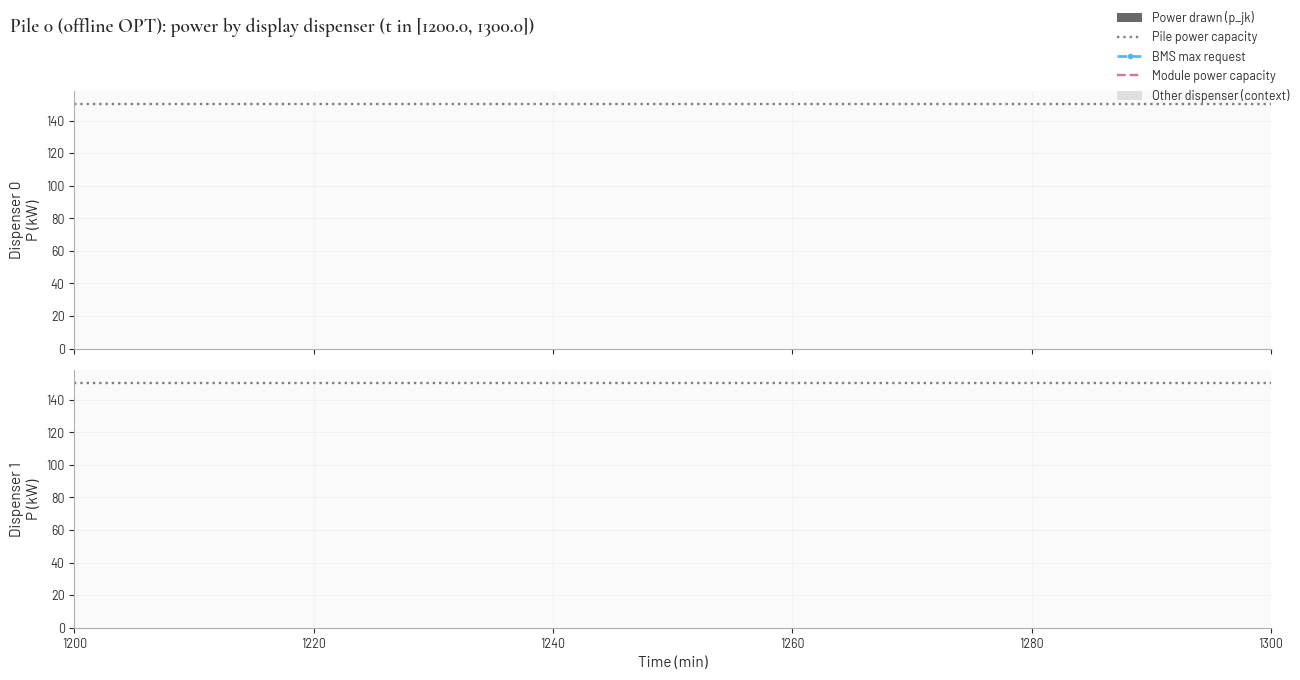

In [7]:
from offline_opt import plot_pile_power_and_modules
import matplotlib.pyplot as plt

fig = plot_pile_power_and_modules(
    ip_model,
    pile_id=0,                    # <- enter a pile id here
    t_start=1200,                  # <- enter a time-window subset (None -> actual activity on this pile)
    t_end=1300,
    stack_other_connectors=True,     # toggle: stack other connectors' power on top
    other_alpha=0.3,             #         (same pile, low alpha, for context)
    show_bms_request=True,
    show_modules=True,
    bar_width=0.9,
    show_ev_ids=True,
    show_pile_capacity=True
)
fig

Plotting EV 10 (pile 0, connector 1), charts=['P-S', 'T-S', 'P-T'], trace_len=4
Plotting EV 11 (pile 0, connector 0), charts=['P-S', 'T-S', 'P-T'], trace_len=2
Plotting EV 12 (pile 0, connector 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 13 (pile 0, connector 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 14 (pile 0, connector 0), charts=['P-S', 'T-S', 'P-T'], trace_len=9


[<Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>]

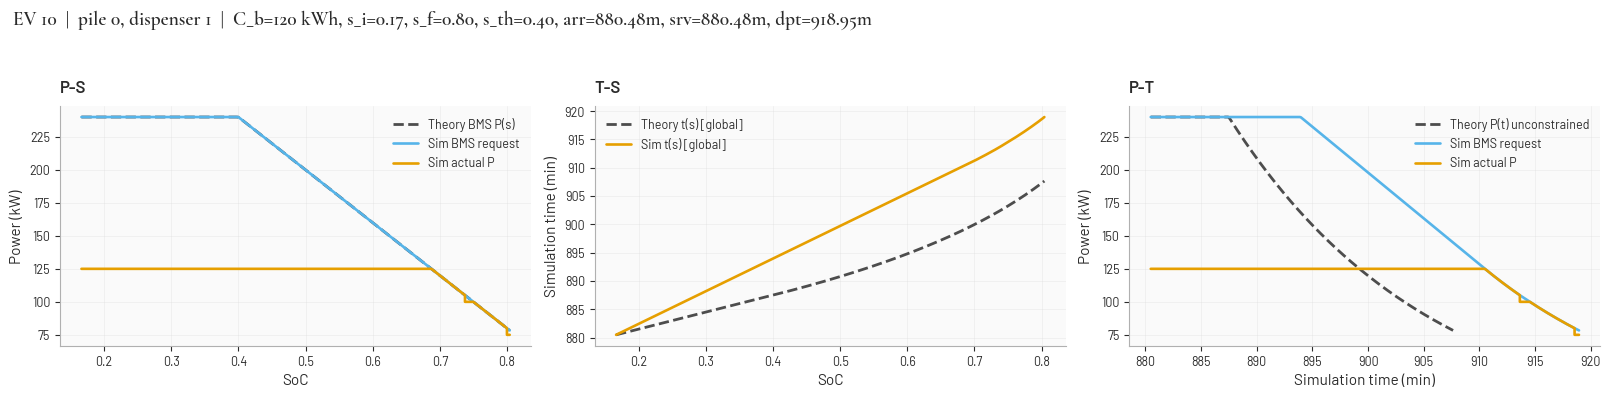

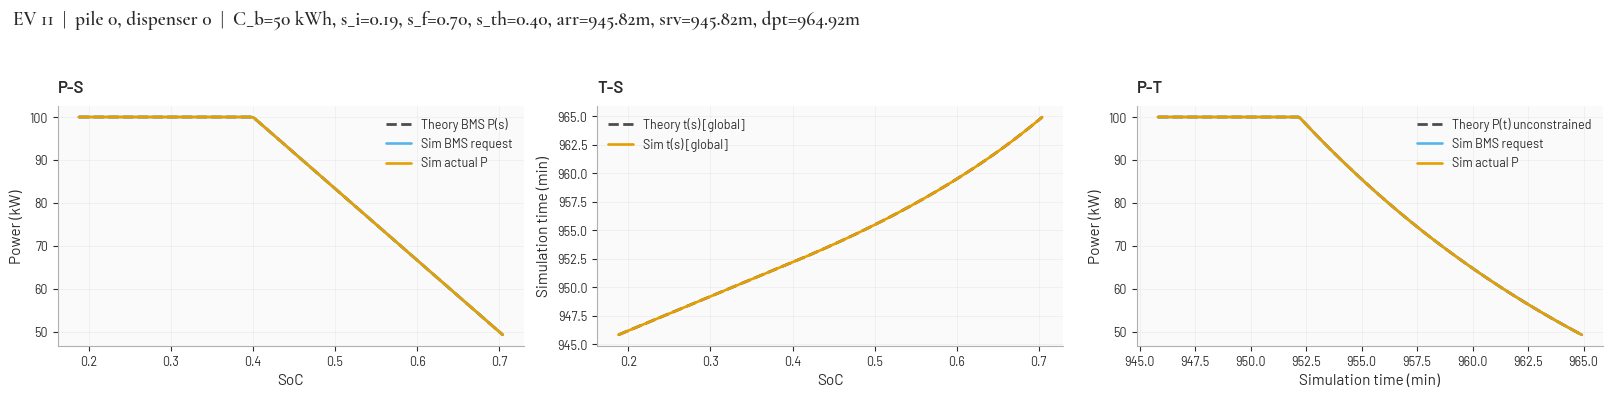

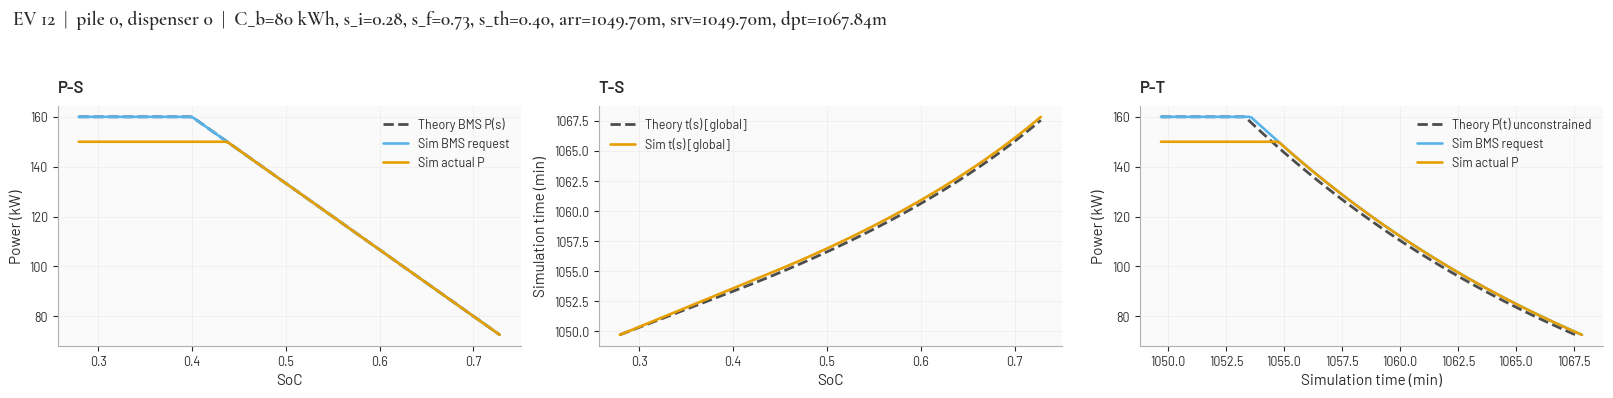

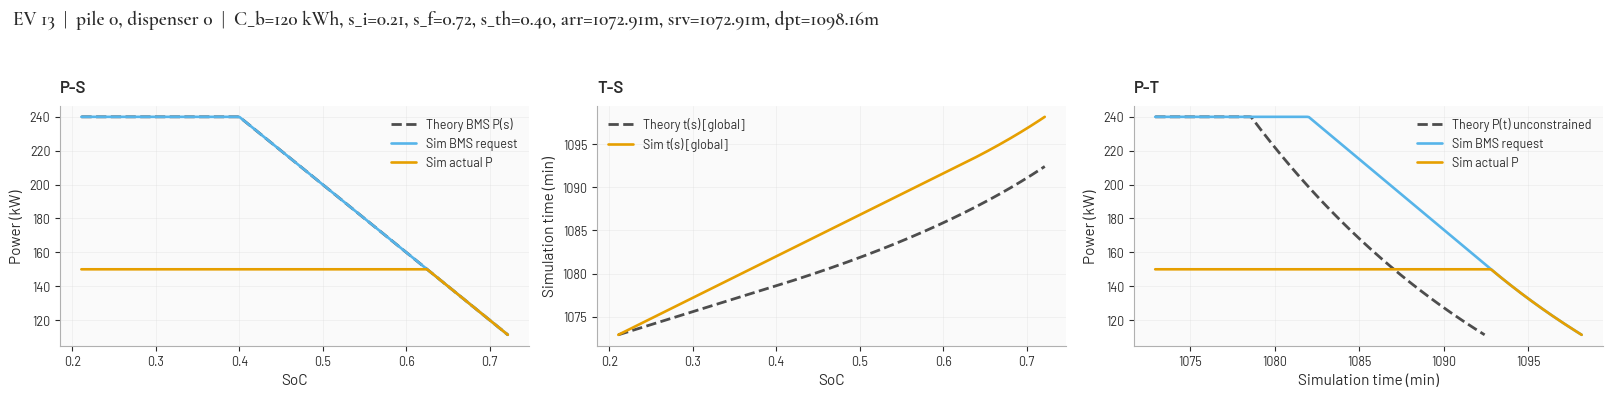

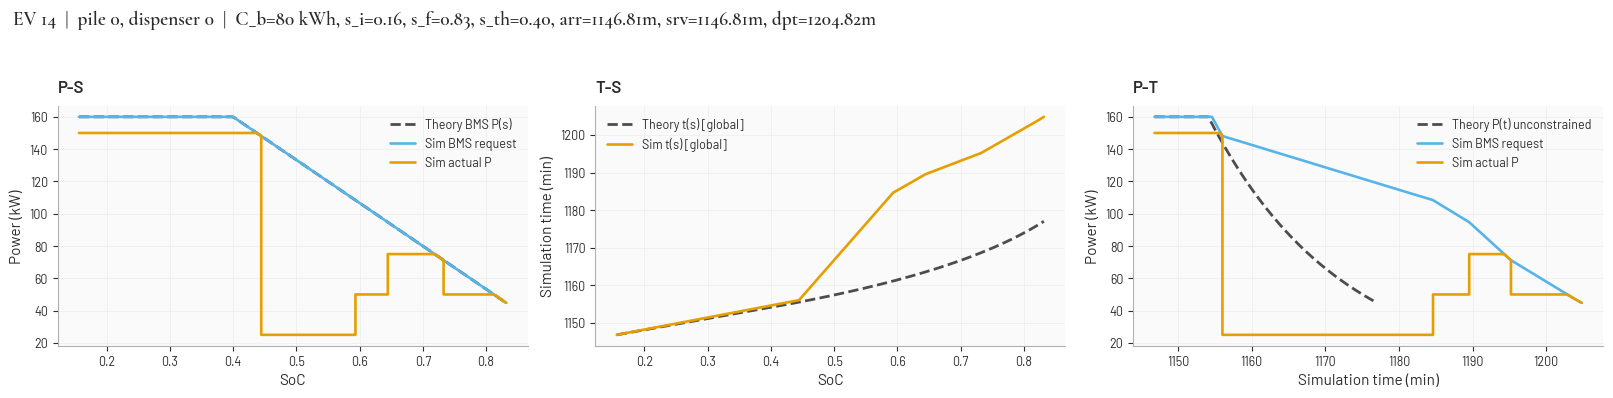

In [17]:
figs = plot_ev_theory_vs_sim(
    env,
    ev_ids=[10 + i for i in range(5)],
    charts=["P-S", "T-S", "P-T"],
    show_theory=True,
    show_sim_bms=True,
    show_sim_actual=True,
    show_recorded_samples=False,
    label_theory=None,
    label_sim_bms=None,
    label_sim_actual=None,
    label_recorded=None,
)
figs
